## Classification

Classification predicts a **category or label**, not a continuous number. Instead of asking "how much?" (regression), it asks "which one?" - a discrete choice from a fixed set of options. The simplest case is **binary classification**: exactly two possible outcomes (Yes/No, Churn/Stay, Spam/Not Spam). There's also **multi-class classification** for more than two categories (e.g., predicting which of 5 product types a customer will buy).

**How it's fundamentally different from regression:**

| | Regression | Classification |
|---|---|---|
| **What it predicts** | A continuous number | A category/label |
| **Output range** | Any number (e.g., $0 to $10,000) | A fixed set of discrete classes (e.g., only "Yes" or "No") |
| **Evaluation** | RMSE, R² (how far off numerically) | Accuracy, precision, recall, F1, confusion matrix (how many predictions landed in the right *bucket*) |
| **"Correctness" means** | Being numerically close | Being exactly right or exactly wrong - there's no "almost churned" |

**Why this distinction actually matters mathematically:** a regression model can be evaluated by measuring *distance* between prediction and truth (predicted $1200 vs actual $1250 is "close"). A classification model can't use distance the same way - predicting "No" when the truth is "Yes" isn't "a little bit wrong," it's just wrong. This is why classification needs entirely different evaluation tools (confusion matrix, precision/recall) instead of RMSE.

**Where your churn project fits in:** `Churn` is a Yes/No column - a textbook binary classification target. This is exactly why regression was useful as a *warm-up and exploration tool* (understanding relationships like tenure vs charges), but the actual prediction task - will this customer churn or not - is classification, not regression.

**Important connecting thread from Logistic Regression specifically (coming up next):** despite having "Regression" in its name, Logistic Regression is actually a **classification** algorithm - it predicts a *probability* (a number between 0 and 1) of belonging to a class, then converts that probability into a Yes/No decision using a threshold (commonly 0.5). This is the bridge between everything just covered and what's coming next.



# Logistic Regression

Despite the name, Logistic Regression is a **classification** algorithm - it predicts the *probability* that something belongs to a category (a number between 0 and 1), then converts that probability into a class decision using a threshold (usually 0.5: probability ≥ 0.5 → "Yes", below → "No").

**Why it can't just use a straight line like Linear Regression:** if a straight line were fit to Yes/No data (encoded as 1/0), it would happily predict values above 1 or below 0 - which makes no sense as a probability. Logistic Regression fixes this by passing the linear equation through a special **S-shaped curve** called the **sigmoid function**, which squashes any output into the range 0 to 1, no matter how large or small the input is.

**The core equation:**
$$p = \frac{1}{1 + e^{-(mx+b)}}$$

This is just the familiar `mx + b` from Linear Regression, fed into the sigmoid function. The sigmoid guarantees the output always lands between 0 and 1, so it can be interpreted as a genuine probability.

**Real example fit:** exactly the churn use case - using `tenure` and `MonthlyCharges` to predict the *probability* a customer churns, then converting that probability into a Yes/No decision. A new customer with short tenure and high monthly charges might get a predicted probability of 0.82 → classified as "will churn."

**Why it's the natural first choice for classification (same role Linear Regression played for regression):** simple, fast, interpretable  the coefficients tell you directly whether a feature increases or decreases churn probability, and by how much. That's exactly why it's the standard baseline model to try first before more complex classifiers like Random Forest or SVM.



In [7]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LogisticRegression


In [8]:
tenure = np.array([1, 2, 5, 8, 12, 20, 30, 40, 50, 60]).reshape(-1, 1)
churn = np.array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0])  # 1 = churned, 0 = stayed

In [9]:
model = LogisticRegression()
model.fit(tenure,churn)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [10]:
prediction = model.predict([[15]])
probability =model.predict_proba([[15]])

In [11]:
print("Prediction for tenure=15:", prediction) 

print("Probability [P(stay), P(churn)]:", probability)
print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

Prediction for tenure=15: [0]
Probability [P(stay), P(churn)]: [[0.98002171 0.01997829]]
Coefficient: [[-0.79236391]]
Intercept: [7.99253011]


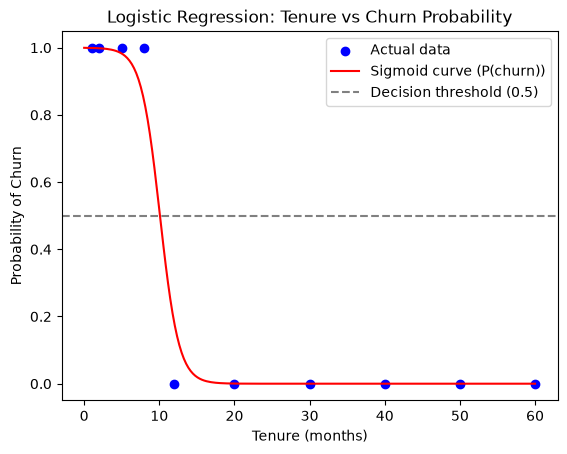

In [12]:
x_range = np.linspace(0, 60, 200).reshape(-1, 1)
y_curve = model.predict_proba(x_range)[:, 1]   # probability of churn

plt.scatter(tenure, churn, color="blue", label="Actual data")
plt.plot(x_range, y_curve, color="red", label="Sigmoid curve (P(churn))")
plt.axhline(0.5, color="gray", linestyle="--", label="Decision threshold (0.5)")
plt.title("Logistic Regression: Tenure vs Churn Probability")
plt.xlabel("Tenure (months)")
plt.ylabel("Probability of Churn")
plt.legend()
plt.savefig("../visuals/logistic_reg_manual.png")
plt.show()

Here's the full math behind logistic regression, using your actual output.

**Step 1 - the linear part inside (same as linear regression)**
$$z = mx + b$$
With `m = -0.79236391` (coefficient) and `b = 7.99253011` (intercept), for tenure=15:
$$z = (-0.79236391 \times 15) + 7.99253011 = -11.885 + 7.993 = -3.893$$

**Step 2 - pass z through the sigmoid function**
$$P(\text{churn}) = \frac{1}{1+e^{-z}}$$
$$P(\text{churn}) = \frac{1}{1+e^{-(-3.893)}} = \frac{1}{1+e^{3.893}}$$

$e^{3.893} \approx 49.05$

$$P(\text{churn}) = \frac{1}{1+49.05} = \frac{1}{50.05} \approx 0.01998$$

This matches your printed output almost exactly: `0.01997829`.

**Step 3 - apply the threshold**
$$0.01998 < 0.5 \rightarrow \text{predict class } 0 \text{ (stay)}$$

**Step 4 - how `m` and `b` themselves got found (fitting process)**
Unlike linear regression's clean mean/deviation formula, logistic regression is fit using **Maximum Likelihood Estimation (MLE)** - an iterative process (similar in spirit to the curve_fit process from non-linear regression):
1. Start with a rough guess for `m` and `b`
2. For every training row, compute the predicted probability using the sigmoid formula above
3. Measure how "wrong" those probabilities were using a specific error formula called **log loss**:
$$\text{Log Loss} = -\frac{1}{n}\sum \left[y_i \ln(p_i) + (1-y_i)\ln(1-p_i)\right]$$
This penalizes confident wrong predictions heavily (e.g., predicting 0.99 probability of churn for someone who actually stayed gets punished hard)
4. Adjust `m` and `b` slightly in the direction that reduces log loss
5. Repeat until log loss stops improving (convergence) - this gives the final `m=-0.79236391, b=7.99253011`

**Why sigmoid specifically, mathematically:** the function $\frac{1}{1+e^{-z}}$ has a special property - no matter how large or negative `z` gets, the output is mathematically guaranteed to stay strictly between 0 and 1:
- Very negative z (like -3.89 here) → $e^{-z}$ becomes huge → fraction becomes tiny → probability near 0
- Very positive z → $e^{-z}$ becomes tiny → fraction approaches 1 → probability near 1
- z = 0 → exactly 0.5, the natural midpoint

**Connecting this back to your coefficient sign question from before:** because `m = -0.79` is negative, larger tenure values make `z` more negative, which pushes `P(churn)` toward 0 (stay) - mathematically confirming what was said earlier: higher tenure → lower churn probability.



There's no fixed rule that 0=no/1=yes always maps the same way in every dataset — **the meaning of 0 and 1 is just a labeling choice made when the data gets encoded**, and it can point in either direction depending on what the model is trying to detect.

| | Class 1 | Class 0 |
|---|---|---|
| **General binary convention** | "Yes" / positive case | "No" / negative case |
| **In this churn example specifically** | Churn = **Yes** (customer left) | Churn = **No** (customer stayed) |

So here, `1` was chosen to mean **"customer churned (left)"** — not because 1 always means "no" or always means "yes" in some universal sense, but because in *this specific mapping*, churn happening was labeled as the positive case (1), and churn not happening (staying) was labeled 0.

**Where that mapping actually happened in the code:**
```python
df["Churn_binary"] = df["Churn"].map({"Yes": 1, "No": 0})
```
This line is the entire source of the confusion — it explicitly says: wherever the original `Churn` column said the text `"Yes"`, replace it with the number `1`; wherever it said `"No"`, replace it with `0`. So `1` here means **"Yes, they churned"** — not a general-purpose "yes" for everything, just yes-to-this-specific-question ("did they churn?").

**The one thing to hold onto:** 0 and 1 don't have fixed universal meanings — they always mean whatever the person who encoded the data decided they mean. Always check the mapping line (like the one above) to know which is which, rather than assuming.

## Example 2 - the real Telco Logistic Regression

the accuracy, confusion matrix, and classification report .

 we'll break down exactly what each number means, including how the confusion matrix maps to false positives/false negatives

In [46]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report 


In [47]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("After load:", df.shape)

After load: (7043, 21)


In [48]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"])
print("After TotalCharges cleanup:", df.shape)

After TotalCharges cleanup: (7032, 21)


In [49]:
df["Churn_binary"] = df["Churn"].map({"Yes": 1, "No": 0})
df = df.dropna(subset=["Churn_binary"])
print("After Churn_binary cleanup:", df.shape)

After Churn_binary cleanup: (7032, 22)


In [50]:
X = df[["tenure", "MonthlyCharges", "TotalCharges"]]
y = df["Churn_binary"]


In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [53]:
y_pred = model.predict(X_test)

In [54]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(" \n  Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\n   Classification Report:\n", classification_report(y_test, y_pred))
print("\n   Coefficients:", model.coef_)

Accuracy: 0.7796730632551528
 
  Confusion Matrix:
 [[937  96]
 [214 160]]

   Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.91      0.86      1033
           1       0.62      0.43      0.51       374

    accuracy                           0.78      1407
   macro avg       0.72      0.67      0.68      1407
weighted avg       0.76      0.78      0.76      1407


   Coefficients: [[-0.06973475  0.03049083  0.00016941]]


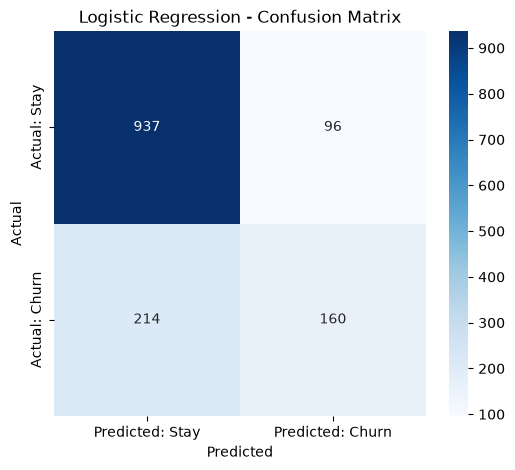

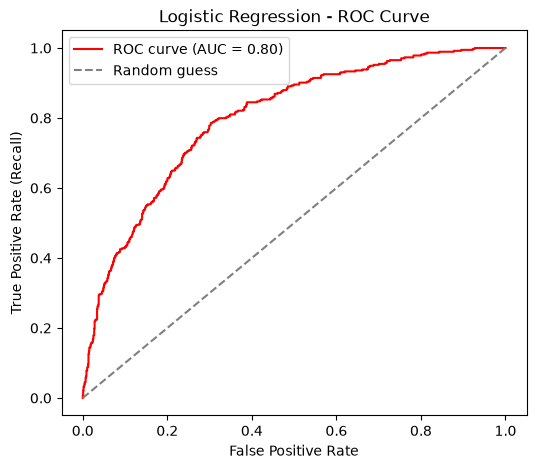

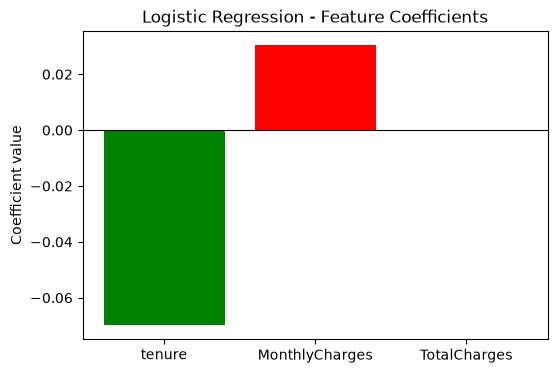

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, ConfusionMatrixDisplay

# 1. Confusion Matrix heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted: Stay", "Predicted: Churn"],
            yticklabels=["Actual: Stay", "Actual: Churn"])
plt.title("Logistic Regression - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.savefig("../visuals/logreg_confusion_matrix.png")
plt.show()

# 2. ROC Curve
y_proba = model.predict_proba(X_test)[:, 1]   # probability of churn
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="red", label=f"ROC curve (AUC = {auc_score:.2f})")
plt.plot([0,1], [0,1], color="gray", linestyle="--", label="Random guess")
plt.title("Logistic Regression - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.legend()
plt.savefig("../visuals/logreg_roc_curve.png")
plt.show()

# 3. Coefficient importance bar chart
features = ["tenure", "MonthlyCharges", "TotalCharges"]
coefs = model.coef_[0]

plt.figure(figsize=(6,4))
plt.bar(features, coefs, color=["green" if c<0 else "red" for c in coefs])
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression - Feature Coefficients")
plt.ylabel("Coefficient value")
plt.savefig("../visuals/logreg_coefficients.png")
plt.show()

## Mathematical breakdown

**Step 1 - the linear combination inside the sigmoid**
With 3 features now instead of 1, the equation extends to:
$$z = w_1(\text{tenure}) + w_2(\text{MonthlyCharges}) + w_3(\text{TotalCharges}) + b$$

Using your actual coefficients:
$$z = (-0.06973475 \times \text{tenure}) + (0.03049083 \times \text{MonthlyCharges}) + (0.00016941 \times \text{TotalCharges}) + b$$

**Step 2 - example calculation for one customer**
Say a customer has `tenure=5`, `MonthlyCharges=90`, `TotalCharges=450`:
$$z = (-0.0697 \times 5) + (0.0305 \times 90) + (0.00017 \times 450) + b$$
$$z = -0.349 + 2.745 + 0.077 + b \approx 2.47 + b$$

**Step 3 - sigmoid converts z to probability**
$$P(\text{churn}) = \frac{1}{1+e^{-z}}$$
With a reasonably positive `z` here, this customer would land with a fairly high churn probability - short tenure + high monthly charges is exactly the profile the model learned to associate with churn (matches the coefficient signs: negative on tenure, positive on MonthlyCharges).

**Step 4 - how fitting found these exact 3 coefficients**
Same Maximum Likelihood Estimation process as before, just extended to 3 dimensions instead of 1 - the model iteratively adjusts all 3 weights + intercept simultaneously, using gradient descent, to minimize log loss across all ~5,625 training rows at once. Each iteration nudges all 4 numbers (`w1, w2, w3, b`) together based on which direction reduces total error most.

**Step 5 - confusion matrix arithmetic, verifying accuracy**
$$\text{Accuracy} = \frac{TP+TN}{TP+TN+FP+FN} = \frac{160+937}{160+937+96+214} = \frac{1097}{1407} = 0.7797$$
Matches your printed 0.7797 exactly.

**Step 6 - the baseline comparison that exposes the paradox**
$$\text{Naive "always predict stay" accuracy} = \frac{1033}{1407} = 0.7342 \text{ (73.4\%)}$$
Your model's 77.97% is only about **4.5 percentage points better** than doing zero actual learning - just always guessing the majority class.

**Step 7 - recall arithmetic (the number that actually exposes the weakness)**
$$\text{Recall (churn)} = \frac{TP}{TP+FN} = \frac{160}{160+214} = \frac{160}{374} = 0.4278$$
Matches your 0.43. This means 214 real churners were completely missed.

---

## Why this happens — the real reasons

**Reason 1 : class imbalance biases the model toward the majority class.** With ~73% of training examples being "stayed," the model's log-loss minimization naturally gravitates toward predictions that favor class 0, since being wrong about the minority class (churn) contributes less to total error simply because there are fewer of those examples to get wrong.

**Reason 2 : 0.5 threshold isn't calibrated for imbalanced data.** The model outputs a probability, but the default cutoff (0.5) was never tuned for this specific class distribution - many borderline churners likely get probabilities like 0.35-0.49, just under the threshold, and get classified as "stay" even though they're genuinely at risk.

**Reason 3 : only 3 numeric features, missing real signal.** `Contract` type, `PaymentMethod`, `InternetService`, `TechSupport` etc. are known strong churn predictors in this dataset (e.g., month-to-month contracts churn far more than 2-year contracts) - none of that categorical information was included, so the model is working with an incomplete picture.

**Reason 4 : logistic regression's linear boundary limits it.** Even with more features, logistic regression can only draw a straight decision boundary (a flat plane in multi-dimensional space) - real churn patterns often involve interactions (e.g., "high charges AND month-to-month AND low tech support" combining multiplicatively, not additively), which this model structurally cannot capture.

---

## How to improve it (concrete next steps)

1. **Add categorical features** : encode `Contract`, `PaymentMethod`, `InternetService`, etc. with one-hot encoding, giving the model access to genuinely predictive signal it's currently missing entirely.
2. **Use `class_weight="balanced"`** in `LogisticRegression()` : this automatically up-weights the minority class during training, directly countering Reason 1.
3. **Adjust the decision threshold** : instead of the default 0.5, lower it (e.g., 0.35) to catch more true churners, accepting more false positives in exchange for fewer missed churners — a legitimate business tradeoff worth making explicit.
4. **Try a non-linear model next** : Decision Tree/Random Forest can capture feature interactions logistic regression structurally cannot, directly addressing Reason 4.
5. **Evaluate with PR-AUC, not just accuracy** : precision-recall curves are more informative than accuracy on imbalanced data, exactly as flagged in that reference document.

